# M3 — Model Selection: RNN + Attention vs Transformer


Both architectures use the same dataset split, tokenizer, batch size, optimiser,
training budget, learning-rate search space, random seed and evaluation metrics.
Architecture-specific parameters are configured separately.

No early stopping; every run uses the same fixed number of epochs

## 1 · Environment

In [1]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available()
      else "No GPU -- open Runtime > Change runtime type > T4 GPU")

GPU: Tesla T4


In [2]:
# The evaluation branch carries the data, tokenizer, both models, evaluate.py and configs
!git clone -q -b evaluation https://github.com/RayYouDS/cits4012-NLP-project.git repo
%cd repo
!pip install -q sentencepiece tqdm tabulate
!find scripts config datasets -maxdepth 2 -type f | sort | head -25

fatal: destination path 'repo' already exists and is not an empty directory.
/content/repo
config/m3_params.json
config/test_rnn_params.json
config/test_transformer_params.json
datasets/inspect_data.ipynb
datasets/MultiRC/test_83-fixedIds.json
datasets/MultiRC/train_456-fixedIds.json
datasets/piqa_sample.csv
datasets/PIQA/test.jsonl
datasets/PIQA/test-labels.lst
datasets/PIQA/train.jsonl
datasets/PIQA/train-labels.lst
datasets/ReClor/test.json
datasets/ReClor/train.json
datasets/TweetQA/test.csv
datasets/TweetQA/train.csv
scripts/data_loader/__init__.py
scripts/data_loader/load_piqa_data.py
scripts/data_loader/piqa_dataloader.py
scripts/evaluation/evaluate.py
scripts/evaluation/__init__.py
scripts/__init__.py
scripts/models/bigru_attention.py
scripts/models/__init__.py
scripts/models/rnn_attention_refactored.py
scripts/models/selfattention.py


### Add the training loop

`trainer.py` is the only file missing from the repository. **Run the cell below and pick
`trainer.py` in the upload dialog.**

It goes under `scripts/training/`, alongside the rest of the package
(`scripts/models/`, `scripts/evaluation/`, ...).

In [3]:
import os, shutil
os.makedirs("scripts/training", exist_ok=True)
open("scripts/training/__init__.py", "a").close()

if not os.path.exists("scripts/training/trainer.py"):
    from google.colab import files
    files.upload()                                   # select trainer.py
    shutil.move("trainer.py", "scripts/training/trainer.py")

print("trainer in place:", os.path.exists("scripts/training/trainer.py"))

trainer in place: True


## 2 · Split and tokenizer

The repository currently splits by row, so different rows sharing a goal end up on
opposite sides: **156 of the 1611 validation rows (9.7%) have a goal the model already
saw in training**, which inflates the validation score.

Changing the split alone is not enough. The committed `piqa_bpe_v2.model` was trained on
the old row-split training subset, so under a group split about **89%** of the new
validation text would have gone into that tokenizer's training corpus. The tokenizer
never sees labels, but this is still preprocessing leakage.

Two self-consistent options:

| `SPLIT_MODE` | Split | Tokenizer | Cost |
|---|---|---|---|
| `"row"` | by row (repository default) | the committed one | 9.7% goal leakage, to be stated as a limitation |
| `"group"` | by goal | **retrained on the new training subset** | about a minute; produces a tokenizer that differs from the committed one |

**Do not combine a group split with the old tokenizer.**

In [ ]:
SPLIT_MODE = "row"          # "group" or "row"
SEED = 4012

from pathlib import Path
import pandas as pd
import subprocess, sys

# Always start from the committed file, then apply the patch only if it is wanted.
# Without this, switching from "group" back to "row" in the same runtime keeps the
# patched file: the cell would print "split by row" while still splitting by goal.
subprocess.run(["git", "checkout", "--", "scripts/data_loader/load_piqa_data.py"], check=False)
sys.modules.pop("scripts.data_loader.load_piqa_data", None)

if SPLIT_MODE == "group":
    src = open("scripts/data_loader/load_piqa_data.py").read()
    old = ('    valid_dataset = train_dataset.sample(n=sample_size, random_state=4012)\n'
           '    train_dataset = train_dataset.drop(valid_dataset.index)')
    new = ('    # Group split: every row of a goal goes to train or to valid, never both\n'
           '    goal_order  = train_dataset["goal"].drop_duplicates().sample(frac=1.0, random_state=4012)\n'
           '    sizes       = train_dataset.groupby("goal").size()\n'
           '    cum         = sizes[goal_order].cumsum()\n'
           '    valid_goals = cum[cum <= sample_size].index\n'
           '\n'
           '    valid_dataset = train_dataset[train_dataset["goal"].isin(valid_goals)]\n'
           '    train_dataset = train_dataset.drop(valid_dataset.index)')
    if old in src:
        open("scripts/data_loader/load_piqa_data.py", "w").write(src.replace(old, new))
        print("switched to a group split by goal")
    else:
        print("load_piqa_data.py already uses a group split, skipping")
else:
    print("using the repository default: random split by row")

from scripts.data_loader.load_piqa_data import piqa_to_dataframe
BASE_PATH = Path('./datasets/PIQA').resolve()
tr_df, va_df, te_df = piqa_to_dataframe(base_path=BASE_PATH)

leak = int(va_df.goal.isin(set(tr_df.goal)).sum())
print(f"train {len(tr_df)}  valid {len(va_df)}  test {len(te_df)}")
print(f"validation rows whose goal appears in train: {leak} ({leak/len(va_df)*100:.1f}%)")
print("validation label counts:", va_df.label.value_counts().sort_index().to_dict())

using the repository default: random split by row
train 14502  valid 1611  test 1838
validation rows whose goal appears in train: 157 (9.7%)
validation label counts: {0: 836, 1: 775}


### Tokenizer

Under `SPLIT_MODE="group"` the tokenizer is retrained on the **new training subset**,
with exactly the settings used in `scripts/tokenizer/train_piqa_tokenizer.py` and only
the corpus changed. No validation or test text then enters the tokenizer at all.

In [7]:
import random, sentencepiece as spm

if SPLIT_MODE == "group":
    corpus = tr_df['goal'].tolist() + tr_df['sol1'].tolist() + tr_df['sol2'].tolist()
    random.Random(SEED).shuffle(corpus)

    with open("scripts/tokenizer/temp_m3_corpus.txt", "w", encoding="utf-8") as f:
        for t in corpus:
            f.write(str(t).replace("\r\n", " ").replace("\n", " ").replace("\r", " ") + "\n")

    spm.SentencePieceTrainer.train(
        input="scripts/tokenizer/temp_m3_corpus.txt",
        model_prefix="scripts/tokenizer/piqa_bpe_m3",
        model_type="bpe", vocab_size=8000,
        character_coverage=1.0, byte_fallback=True,
        unk_id=0, bos_id=1, eos_id=2, pad_id=3,
        user_defined_symbols=["[CLS]", "[SEP]"])

    TOKENIZER_PATH = "scripts/tokenizer/piqa_bpe_m3.model"
    print(f"retrained the tokenizer on the new training subset ({len(corpus)} lines)")
else:
    TOKENIZER_PATH = "scripts/tokenizer/piqa_bpe_v2.model"
    print("using the committed piqa_bpe_v2.model")

tokenizer = spm.SentencePieceProcessor(model_file=TOKENIZER_PATH)
print(f"vocab {tokenizer.vocab_size()}  PAD {tokenizer.pad_id()}  "
      f"[CLS] {tokenizer.piece_to_id('[CLS]')}  [SEP] {tokenizer.piece_to_id('[SEP]')}")

using the committed piqa_bpe_v2.model
vocab 8000  PAD 3  [CLS] 4  [SEP] 5


## 3 · Hyperparameters (shared by both models apart from the learning rate)

In [8]:
import json, os
os.makedirs("config", exist_ok=True)

LEARNING_RATES = [1e-3, 3e-4]        # each model tries both; the better one is kept

M3_PARAMS = {
    "seed": SEED,
    "split_mode": SPLIT_MODE,
    "tokenizer": TOKENIZER_PATH,
    "batch_size": 64,
    "epochs": 60,                    # fixed budget, no early stopping
    "embedding_dim": 100,

    "hidden_size": 100,              # RNN only
    "architecture": "gru",
    "bidirectional": True,
    "enable_attention": True,

    "num_heads": 4,                  # Transformer only
    "num_layers": 3,

    "learning_rates_searched": LEARNING_RATES,
}
with open("config/m3_params.json", "w") as f:
    json.dump(M3_PARAMS, f, indent=2)

print(json.dumps(M3_PARAMS, indent=2))
print(f"\n2 models x {len(LEARNING_RATES)} learning rates = {2*len(LEARNING_RATES)} runs")

{
  "seed": 4012,
  "split_mode": "row",
  "tokenizer": "scripts/tokenizer/piqa_bpe_v2.model",
  "batch_size": 64,
  "epochs": 60,
  "embedding_dim": 100,
  "hidden_size": 100,
  "architecture": "gru",
  "bidirectional": true,
  "enable_attention": true,
  "num_heads": 4,
  "num_layers": 3,
  "learning_rates_searched": [
    0.001,
    0.0003
  ]
}

2 models x 2 learning rates = 4 runs


## 4 · Reference floors

"Always pick the shorter candidate" is a fixed rule that does not look at the validation
labels. Taking `max(acc, 1 - acc)` would instead choose between "shorter" and "longer"
using those labels, which is a form of peeking.

In [9]:
# sol1 longer -> predict 1, i.e. choose sol2, the shorter of the two
pred_shorter = (va_df["sol1"].str.len() > va_df["sol2"].str.len()).astype(int)
trivial_acc = float((pred_shorter == va_df["label"]).mean())

FLOORS = {"random guess": 0.5, "always pick shorter": trivial_acc}
for k, v in FLOORS.items():
    print(f"{k:<22} = {v:.4f}")
print("\nA model scoring below these has not learned anything.")

random guess           = 0.5000
always pick shorter    = 0.5096

A model scoring below these has not learned anything.


## 5 · DataLoaders and models

`get_piqa_dataloaders` builds the train loader with `shuffle=True` and no generator of
its own, so the batch order comes from the global torch RNG. Constructing a model
consumes random numbers, and the RNN and the Transformer consume different amounts, so
the two would otherwise see different batch orders. The patch below gives the train
loader its own generator, reseeded for each run, so **all four runs see the training
examples in the same order**.

In [10]:
src = open("scripts/data_loader/piqa_dataloader.py").read()
old = "def get_piqa_dataloaders(base_path:Path, tokenizer, batch_size:int):"
new = "def get_piqa_dataloaders(base_path:Path, tokenizer, batch_size:int, generator=None):"
if old in src and "generator=None" not in src:
    src = src.replace(old, new)
    src = src.replace("        batch_size=batch_size,\n        shuffle=True,",
                      "        batch_size=batch_size,\n        shuffle=True,\n        generator=generator,")
    open("scripts/data_loader/piqa_dataloader.py", "w").write(src)
    print("train loader now takes its own generator")
else:
    print("piqa_dataloader.py already supports a generator, skipping")

train loader now takes its own generator


In [11]:
import torch
from scripts.data_loader.piqa_dataloader import get_piqa_dataloaders
from scripts.models.rnn_attention_refactored import RNNWithAttention
from scripts.models.transformer_bi_classifier import TransformerClassifier
from scripts.evaluation.evaluate import evaluate, compute_metrics
from scripts.training.trainer import train, set_seed

p = M3_PARAMS

def build_loaders():
    g = torch.Generator(); g.manual_seed(p["seed"])     # same batch order for every run
    return get_piqa_dataloaders(base_path=BASE_PATH, tokenizer=tokenizer,
                                batch_size=p["batch_size"], generator=g)

def build_rnn():
    set_seed(p["seed"])
    return RNNWithAttention(vocab_size=tokenizer.vocab_size(),
                            embedding_dim=p["embedding_dim"], hidden_dim=p["hidden_size"],
                            padding_idx=tokenizer.pad_id(), architecture=p["architecture"],
                            bidirectional=p["bidirectional"], enable_attention=p["enable_attention"])

def build_transformer():
    set_seed(p["seed"])
    return TransformerClassifier(vocab_size=tokenizer.vocab_size(),
                                 embedding_dim=p["embedding_dim"], padding_idx=tokenizer.pad_id(),
                                 max_seq_length=2048, num_heads=p["num_heads"],
                                 num_layers=p["num_layers"])

BUILDERS = {"rnn": build_rnn, "transformer": build_transformer}

for name, b in BUILDERS.items():
    m = b()
    tot = sum(q.numel() for q in m.parameters())
    emb = sum(q.numel() for n_, q in m.named_parameters() if "embedding" in n_ and "position" not in n_)
    print(f"{name:<12} total params {tot:>9,}   non-embedding {tot-emb:>9,}")

rnn          total params 1,042,001   non-embedding   242,001
transformer  total params   999,985   non-embedding   199,985


## 6 · Run the 2 x 2 grid

`test_dataloader=None`: M3 does not evaluate on the official test set or use its labels
for model selection. It is reserved for final evaluation after the main model is frozen.

In [12]:
import os, time
OUT = "reports/m3_results"      # not runs/ -- .gitignore excludes any directory called runs
os.makedirs(OUT, exist_ok=True)

runs = {}
t0 = time.time()
for name, builder in BUILDERS.items():
    for lr in LEARNING_RATES:
        cfg = dict(M3_PARAMS); cfg["learning_rate"] = lr
        train_loader, validate_loader, _ = build_loaders()
        model = builder()
        print("=" * 84)
        history, summary = train(
            model, train_loader, validate_loader, cfg,
            evaluate_fn=evaluate, compute_metrics_fn=compute_metrics,
            test_dataloader=None,                      # test set stays untouched
            model_name=name, out_dir=OUT, run_id=f"m3_{name}_lr{lr:g}")
        runs[(name, lr)] = (history, summary)
        print()

print(f"{len(runs)} runs finished in {(time.time()-t0)/60:.1f} minutes")

[m3_rnn_lr0.001] rnn | params 1,042,001 (non-embedding 242,001) | lr 0.001 | epochs 60 | device cuda


Epochs: 1 | Train Loss:  0.689 | Train Accuracy:  0.530 | Val Loss:  0.683 | Val Accuracy:  0.561 | 0m 13s (- 13m 20s)  * best


Epochs: 2 | Train Loss:  0.658 | Train Accuracy:  0.603 | Val Loss:  0.695 | Val Accuracy:  0.553 | 0m 25s (- 12m 17s)


Epochs: 3 | Train Loss:  0.594 | Train Accuracy:  0.671 | Val Loss:  0.723 | Val Accuracy:  0.576 | 0m 37s (- 11m 43s)  * best


Epochs: 4 | Train Loss:  0.485 | Train Accuracy:  0.759 | Val Loss:  0.825 | Val Accuracy:  0.569 | 0m 48s (- 11m 18s)


...

Epochs: 56 | Train Loss:  0.201 | Train Accuracy:  0.911 | Val Loss:  1.338 | Val Accuracy:  0.557 | 10m 1s (- 0m 42s)


Epochs: 57 | Train Loss:  0.204 | Train Accuracy:  0.915 | Val Loss:  1.298 | Val Accuracy:  0.566 | 10m 11s (- 0m 32s)


Epochs: 58 | Train Loss:  0.203 | Train Accuracy:  0.918 | Val Loss:  1.299 | Val Accuracy:  0.566 | 10m 22s (- 0m 21s)


Epochs: 59 | Train Loss:  0.202 | Train Accuracy:  0.914 | Val Loss:  1.425 | Val Accuracy:  0.556 | 10m 33s (- 0m 10s)


Epochs: 60 | Train Loss:  0.192 | Train Accuracy:  0.920 | Val Loss:  1.310 | Val Accuracy:  0.564 | 10m 44s (- 0m 0s)

4 runs finished in 44.9 minutes


## 7 · Pick the learning rate, then compare the models

The best epoch comes from `summary["best_valid_accuracy"]` and `summary["best_epoch"]`,
which the trainer records correctly.

`history[history.is_best].iloc[0]` would be wrong: `is_best` marks every epoch that set a
new record, and the first epoch always does, so `.iloc[0]` always returns epoch 1.

In [13]:
import pandas as pd
from tabulate import tabulate

def best_row(history):
    return history.loc[history["valid_accuracy"].idxmax()]

# Table 1 -- learning-rate search
t1 = [["", *[f"lr={lr:g}" for lr in LEARNING_RATES]]]
for name in BUILDERS:
    t1.append([f"{name} valid acc"] +
              [f"{runs[(name, lr)][1]['best_valid_accuracy']:.4f}" for lr in LEARNING_RATES])
print("Learning-rate search (by validation accuracy)")
print(tabulate(t1, headers="firstrow", tablefmt="fancy_grid"))

BEST_LR = {n: max(LEARNING_RATES, key=lambda lr: runs[(n, lr)][1]["best_valid_accuracy"])
           for n in BUILDERS}
print("\nselected learning rates:", {k: f"{v:g}" for k, v in BEST_LR.items()}, "\n")

# Table 2 -- model comparison, validation metrics only
best = {n: runs[(n, BEST_LR[n])] for n in BUILDERS}
names = list(BUILDERS)
t2 = [["", *[n.upper() for n in names]]]
t2.append(["Learning rate"] + [f"{BEST_LR[n]:g}" for n in names])
for key, label in [("accuracy","Valid Accuracy"), ("f1","Valid macro F1"),
                   ("precision","Valid Precision"), ("recall","Valid Recall")]:
    t2.append([label] + [f"{best_row(best[n][0])['valid_'+key]:.4f}" for n in names])
t2.append(["Best Epoch"]        + [str(best[n][1]["best_epoch"]) for n in names])
t2.append(["Params"]            + [f"{best[n][1]['n_params']:,}" for n in names])
t2.append(["Params (non-emb)"]  + [f"{best[n][1]['n_params_no_embedding']:,}" for n in names])
t2.append(["Train time (s)"]    + [f"{best[n][0].epoch_seconds.sum():.0f}" for n in names])

print("Model comparison (each at its own best learning rate, validation only)")
print(tabulate(t2, headers="firstrow", tablefmt="fancy_grid"))
print(f"\nrandom guess = {FLOORS['random guess']:.4f}"
      f"   always pick shorter = {FLOORS['always pick shorter']:.4f}")

WINNER = max(names, key=lambda n: runs[(n, BEST_LR[n])][1]["best_valid_accuracy"])
w = runs[(WINNER, BEST_LR[WINNER])][1]
print(f"\nM3 result: main model = {WINNER.upper()} "
      f"(lr={BEST_LR[WINNER]:g}, valid acc {w['best_valid_accuracy']:.4f}, epoch {w['best_epoch']})")
print("No official test metrics were used; final evaluation follows model freezing.")

all_history = pd.concat([h for h, _ in runs.values()], ignore_index=True)
all_history.to_csv(f"{OUT}/m3_all_history.csv", index=False)
with open(f"{OUT}/m3_selection.json", "w") as f:
    json.dump({"split_mode": SPLIT_MODE, "tokenizer": TOKENIZER_PATH,
               "best_lr": {k: float(v) for k, v in BEST_LR.items()},
               "winner": WINNER, "floors": FLOORS,
               "valid_accuracy": {f"{n}_lr{lr:g}": runs[(n,lr)][1]["best_valid_accuracy"]
                                  for n in BUILDERS for lr in LEARNING_RATES}}, f, indent=2)
all_history.head()

Learning-rate search (by validation accuracy)
╒═══════════════════════╤════════════╤═════════════╕
│                       │   lr=0.001 │   lr=0.0003 │
╞═══════════════════════╪════════════╪═════════════╡
│ rnn valid acc         │     0.5773 │      0.586  │
├───────────────────────┼────────────┼─────────────┤
│ transformer valid acc │     0.5872 │      0.5835 │
╘═══════════════════════╧════════════╧═════════════╛

selected learning rates: {'rnn': '0.0003', 'transformer': '0.001'} 

Model comparison (each at its own best learning rate, validation only)
╒══════════════════╤═══════════╤═══════════════╕
│                  │ RNN       │ TRANSFORMER   │
╞══════════════════╪═══════════╪═══════════════╡
│ Learning rate    │ 0.0003    │ 0.001         │
├──────────────────┼───────────┼───────────────┤
│ Valid Accuracy   │ 0.5860    │ 0.5872        │
├──────────────────┼───────────┼───────────────┤
│ Valid macro F1   │ 0.5859    │ 0.5866        │
├──────────────────┼───────────┼───────────────┤
│

,run_id,model,epoch,train_loss,train_accuracy,train_precision,train_recall,train_f1,valid_loss,valid_accuracy,valid_precision,valid_recall,valid_f1,acc_gap,grad_norm_mean,grad_norm_max,train_seconds,valid_seconds,epoch_seconds,is_best
0,m3_rnn_lr0.001,rnn,1,0.689234,0.529720,0.529701,0.529699,0.529697,0.682687,0.561142,0.561250,0.561336,0.561028,-0.031422,0.087321,0.172026,13.06,0.47,13.56,True
1,m3_rnn_lr0.001,rnn,2,0.658031,0.602744,0.602739,0.602740,0.602739,0.694570,0.553073,0.552154,0.552054,0.552049,0.049672,0.221495,0.357433,11.34,0.54,11.88,False
2,m3_rnn_lr0.001,rnn,3,0.593927,0.670804,0.670805,0.670808,0.670802,0.722898,0.576040,0.575626,0.575690,0.575631,0.094764,0.439155,0.803735,10.90,0.67,11.60,True
3,m3_rnn_lr0.001,rnn,4,0.484838,0.759206,0.759201,0.759205,0.759202,0.825008,0.569212,0.568593,0.568593,0.568593,0.189994,0.748210,1.348680,10.76,0.66,11.42,False
4,m3_rnn_lr0.001,rnn,5,0.336748,0.846090,0.846088,0.846085,0.846086,1.180136,0.556797,0.556739,0.556820,0.556611,0.289293,1.061804,1.640139,11.01,0.44,11.46,False


## 8 · Figures

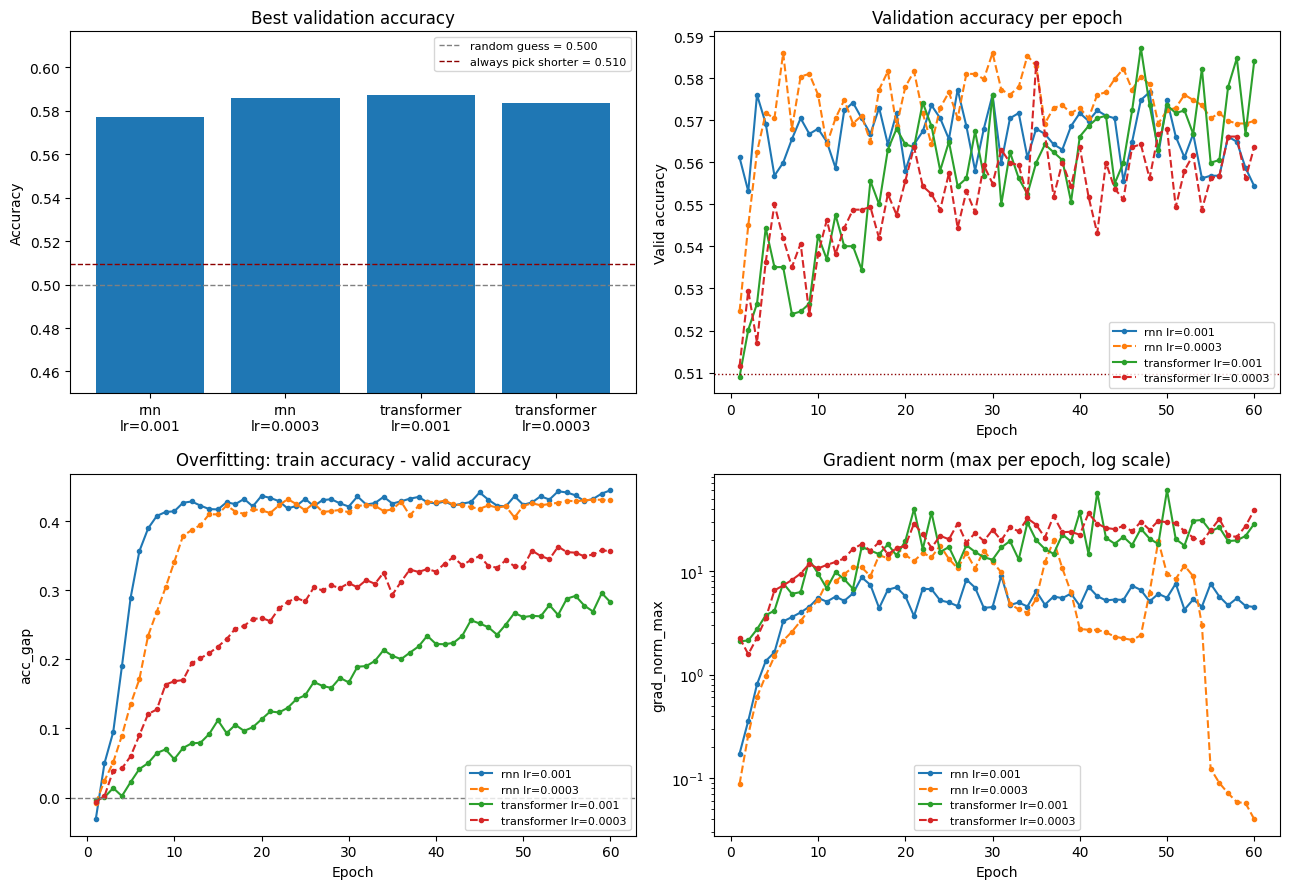

In [ ]:
import matplotlib.pyplot as plt
STYLE = {LEARNING_RATES[0]: "-", LEARNING_RATES[1]: "--"}
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]                                     # bar chart
labels = [f"{n}\nlr={lr:g}" for n in BUILDERS for lr in LEARNING_RATES]
vals   = [runs[(n, lr)][1]["best_valid_accuracy"] for n in BUILDERS for lr in LEARNING_RATES]
ax.bar(labels, vals)
for k, (lab, v) in enumerate(FLOORS.items()):
    ax.axhline(v, ls="--", lw=1, color=["gray","darkred"][k], label=f"{lab} = {v:.3f}")
ax.set_title("Best validation accuracy"); ax.set_ylabel("Accuracy"); ax.set_ylim(0.45, None)
ax.legend(fontsize=8)

ax = axes[0, 1]                                     #  where the curve flattens
for (n, lr), (h, _) in runs.items():
    ax.plot(h.epoch, h.valid_accuracy, STYLE[lr], marker="o", ms=3, label=f"{n} lr={lr:g}")
ax.axhline(FLOORS["always pick shorter"], ls=":", lw=1, color="darkred")
ax.set_title("Validation accuracy per epoch"); ax.set_xlabel("Epoch"); ax.set_ylabel("Valid accuracy")
ax.legend(fontsize=8)

ax = axes[1, 0]                                     # overfitting
for (n, lr), (h, _) in runs.items():
    ax.plot(h.epoch, h.acc_gap, STYLE[lr], marker="o", ms=3, label=f"{n} lr={lr:g}")
ax.axhline(0, ls="--", lw=1, color="gray")
ax.set_title("Overfitting: train accuracy - valid accuracy"); ax.set_xlabel("Epoch")
ax.set_ylabel("acc_gap"); ax.legend(fontsize=8)

ax = axes[1, 1]                                     # gradient norms
for (n, lr), (h, _) in runs.items():
    ax.plot(h.epoch, h.grad_norm_max, STYLE[lr], marker="o", ms=3, label=f"{n} lr={lr:g}")
ax.set_yscale("log")
ax.set_title("Gradient norm (max per epoch, log scale)"); ax.set_xlabel("Epoch")
ax.set_ylabel("grad_norm_max"); ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig(f"{OUT}/m3_curves.png", dpi=150); plt.show()

## 9 · Collect and download

The ZIP has to carry the tokenizer as well. Under `SPLIT_MODE="group"` the tokenizer was
retrained, and loading a checkpoint with the committed `piqa_bpe_v2.model` instead would
silently misalign every token id: the vocabulary size is still 8000, so nothing would
raise, but the attention maps and predictions would be meaningless.

Use the winning model's `best.pt`, its `best_predictions.csv` **and the tokenizer**
for the M6 attention heatmaps and success/failure analysis.

In [15]:
import shutil
from pathlib import Path

OUTP = Path(OUT)

# the tokenizer the checkpoints were trained with
shutil.copy(TOKENIZER_PATH, OUTP / Path(TOKENIZER_PATH).name)
vocab = Path(TOKENIZER_PATH).with_suffix(".vocab")
if vocab.exists():
    shutil.copy(vocab, OUTP / vocab.name)

# the exact configuration needed to reconstruct these runs with the repository code
shutil.copy("config/m3_params.json", OUTP / "m3_params.json")

# which goals ended up in validation, so the split can be checked later
va_df[["goal"]].drop_duplicates().to_csv(OUTP / "validation_goals.csv", index=False)

print("contents of", OUT)
for f in sorted(OUTP.iterdir()):
    print(f"  {f.name:<48} {f.stat().st_size/1024:>9.1f} KB")

!cd reports && zip -qr m3_results.zip m3_results
from google.colab import files
files.download("reports/m3_results.zip")

contents of reports/m3_results
  m3_all_history.csv                                    70.1 KB
  m3_curves.png                                        375.6 KB
  m3_params.json                                         0.3 KB
  m3_rnn_lr0.0003_best.pt                             4075.2 KB
  m3_rnn_lr0.0003_best_predictions.csv                  74.3 KB
  m3_rnn_lr0.0003_history.csv                           17.1 KB
  m3_rnn_lr0.0003_summary.json                           0.7 KB
  m3_rnn_lr0.001_best.pt                              4075.2 KB
  m3_rnn_lr0.001_best_predictions.csv                   75.7 KB
  m3_rnn_lr0.001_history.csv                            17.3 KB
  m3_rnn_lr0.001_summary.json                            0.7 KB
  m3_selection.json                                      0.4 KB
  m3_transformer_lr0.0003_best.pt                     4721.6 KB
  m3_transformer_lr0.0003_best_predictions.csv          75.5 KB
  m3_transformer_lr0.0003_history.csv                   18.2 KB
  m3_tran

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>